In [ ]:
from google.colab import drive
drive.mount('/content/drive')
folder = ('/content/drive/MyDrive/Colab Notebooks/BI/Data')

Mounted at /content/drive


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gc
import os

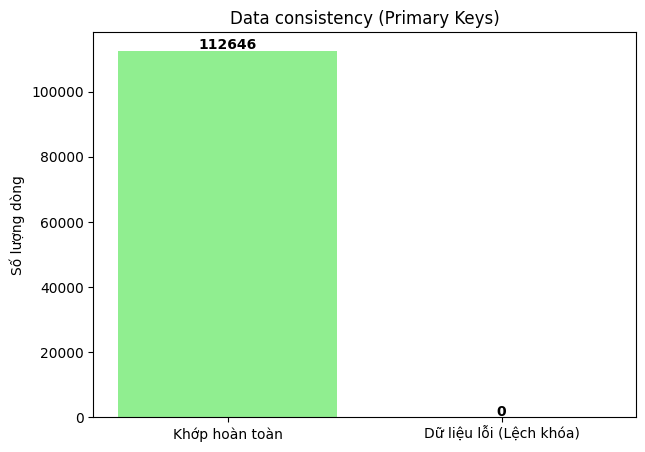

In [ ]:
orders = pd.read_excel(folder + '/Order.xlsx', sheet_name = 'Order')
items = pd.read_excel(folder + '/Order Item.xlsx', sheet_name = 'Order item')

# Kiểm tra xem có bao nhiêu order_id trong bảng items không tồn tại trong bảng orders
missing_keys = ~items['order_id'].isin(orders['order_id'])
match_count = [items.shape[0] - missing_keys.sum(), missing_keys.sum()]

plt.figure(figsize=(7, 5))
plt.bar(['Khớp hoàn toàn', 'Dữ liệu lỗi (Lệch khóa)'], match_count, color=['lightgreen', 'plum'])
plt.title('Data consistency (Primary Keys)')
plt.ylabel('Số lượng dòng')
for i, v in enumerate(match_count):
    plt.text(i, v + 500, str(v), ha='center', fontweight='bold')
plt.show()

##Các bảng đã được chuẩn hóa với các khóa chính và khóa ngoại rất rõ ràng. Việc join các bảng không lo bị trùng lặp dữ liệu nghiêm trọng.

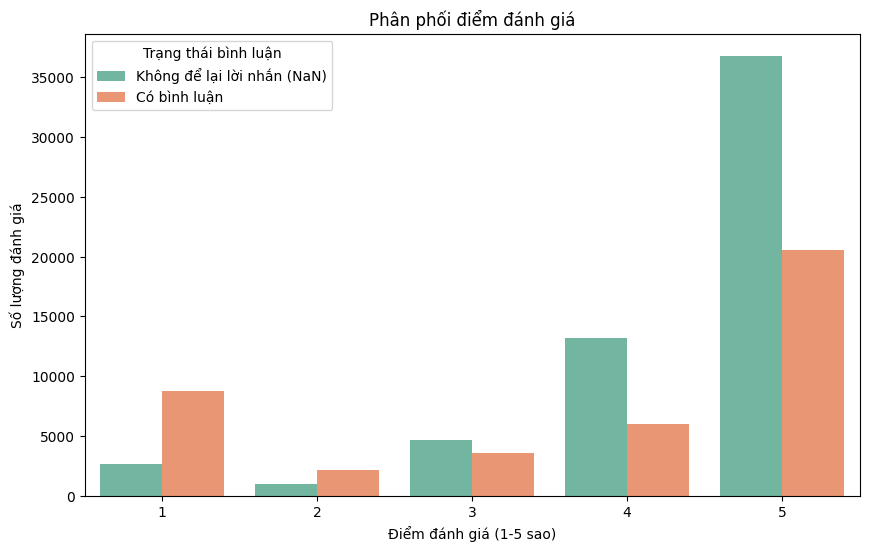

In [ ]:
reviews = pd.read_excel(folder + '/Order Review.xlsx', sheet_name= 'Order review')

# Tạo cột phân loại: Có bình luận hay không
reviews['has_comment'] = reviews['review_comment_message'].notnull().map({True: 'Có bình luận', False: 'Không để lại lời nhắn (NaN)'})

plt.figure(figsize=(10, 6))
sns.countplot(data=reviews, x='review_score', hue='has_comment', palette='Set2')
plt.title('Phân phối điểm đánh giá')
plt.xlabel('Điểm đánh giá (1-5 sao)')
plt.ylabel('Số lượng đánh giá')
plt.legend(title='Trạng thái bình luận')
plt.show()

##Các giá trị thiếu (NaN) trong cột không phải là lỗi dữ liệu, mà là thông tin: nó cho thấy khách hàng hài lòng/không có gì phàn nàn nên không viết nhận xét.

##Nhóm 5 sao thường không để lại lời nhắn (NaN). Xóa các dòng này sẽ làm lệch hoàn toàn bức tranh về sự hài lòng của khách hàng.

/tmp/ipykernel_20879/1612862094.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=order_status.index, y=order_status.values, palette='coolwarm')


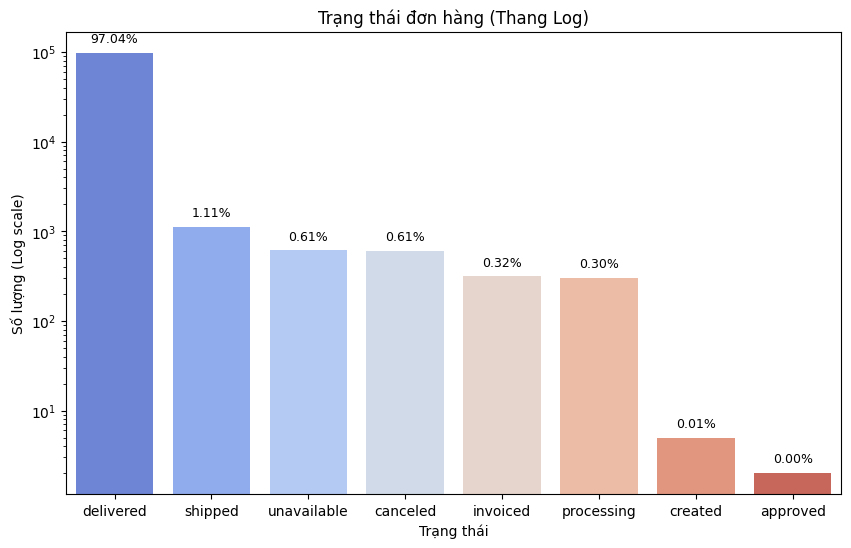

In [ ]:
order_status = orders['order_status'].value_counts()

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=order_status.index, y=order_status.values, palette='coolwarm')
plt.yscale('log') # Dùng thang log để thấy rõ các trạng thái ít phổ biến
plt.title('Trạng thái đơn hàng (Thang Log)')
plt.xlabel('Trạng thái')
plt.ylabel('Số lượng (Log scale)')

# Ghi chú tỷ lệ % trên đầu cột
total = order_status.sum()
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.2f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points', fontsize=9)
plt.show()

## Các đơn hàng bị hủy (canceled) phản ánh đúng tình trạng vận hành của doanh nghiệp, không nên xóa bỏ vì giúp phân tích rủi ro.

##Các trạng thái không phải delivered chỉ chiếm tỷ lệ cực nhỏ (<3%). Việc giữ lại chúng giúp phân tích tại sao đơn hàng bị hủy thay vì xóa bỏ chúng như dữ liệu lỗi.

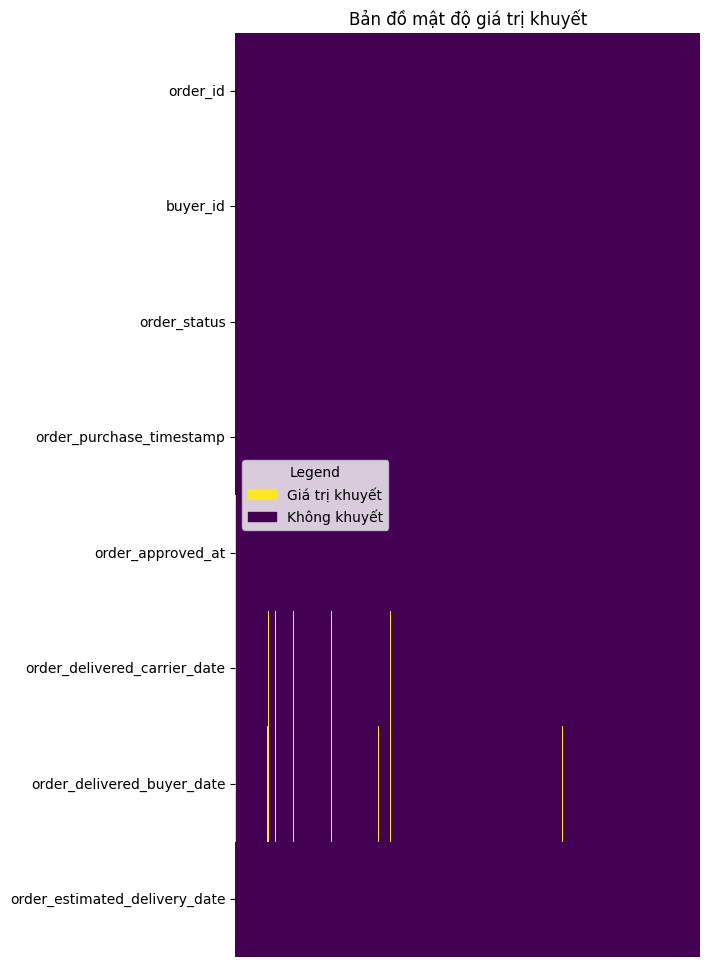

In [ ]:
import matplotlib.patches as mpatches

plt.figure(figsize=(6, 12))
sns.heatmap(orders.isnull().T, yticklabels=True, xticklabels=False, cbar=False, cmap='viridis')
plt.title('Bản đồ mật độ giá trị khuyết')

viridis_cmap = plt.get_cmap('viridis')
missing_patch = mpatches.Patch(color=viridis_cmap(1.0), label='Giá trị khuyết')
not_missing_patch = mpatches.Patch(color=viridis_cmap(0.0), label='Không khuyết')

plt.legend(handles=[missing_patch, not_missing_patch], title='Legend', loc='center left')
plt.show()

##Biểu đồ hầu hết là màu tím (hoặc màu tối), nghĩa là dữ liệu cực kỳ đầy đủ.

##Các vạch vàng chỉ xuất hiện ở các cột thời gian giao hàng (đối với đơn chưa giao), đây là logic nghiệp vụ, không phải lỗi thu thập dữ liệu.

Tìm thấy 10 file dữ liệu: ['Order.xlsx', 'Order Item.xlsx', 'Order Review.xlsx', 'Order Payment.xlsx', 'Buyer.xlsx', 'Closed Deals.xlsx', 'Geolocation.xlsx', 'Marketing Qualified Leads.xlsx', 'Product.xlsx', 'Seller.xlsx']

--- Đang xử lý file: Order.xlsx ---
 > Dữ liệu sheet 'Explanation' không cần tiền xử lí (metadata hoặc giá trị không cần thiết cho tiền xử lí).
 > Dữ liệu sheet 'Order' không cần tiền xử lí (metadata hoặc giá trị không cần thiết cho tiền xử lí).

--- Đang xử lý file: Order Item.xlsx ---
 > Dữ liệu sheet 'Explanation' không cần tiền xử lí (metadata hoặc giá trị không cần thiết cho tiền xử lí).


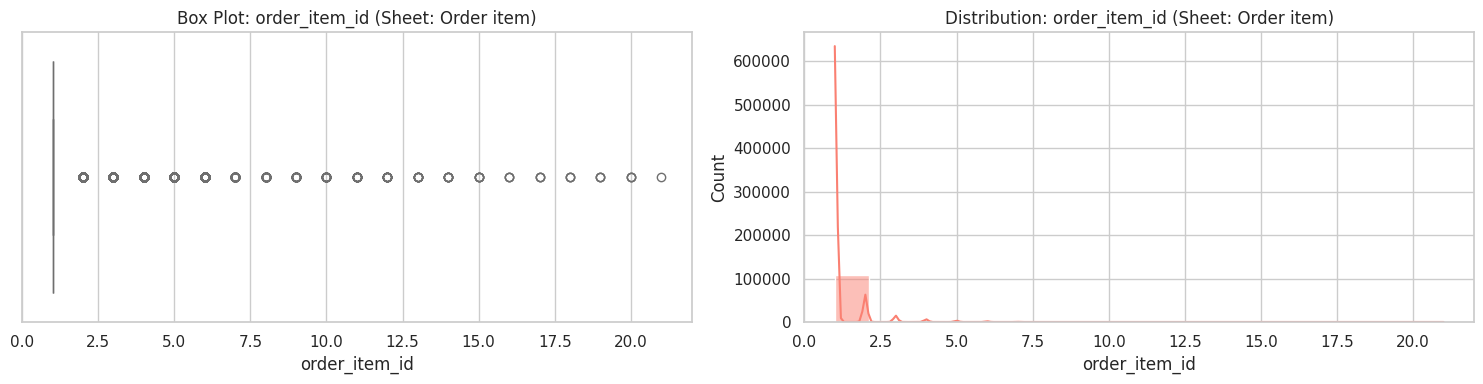

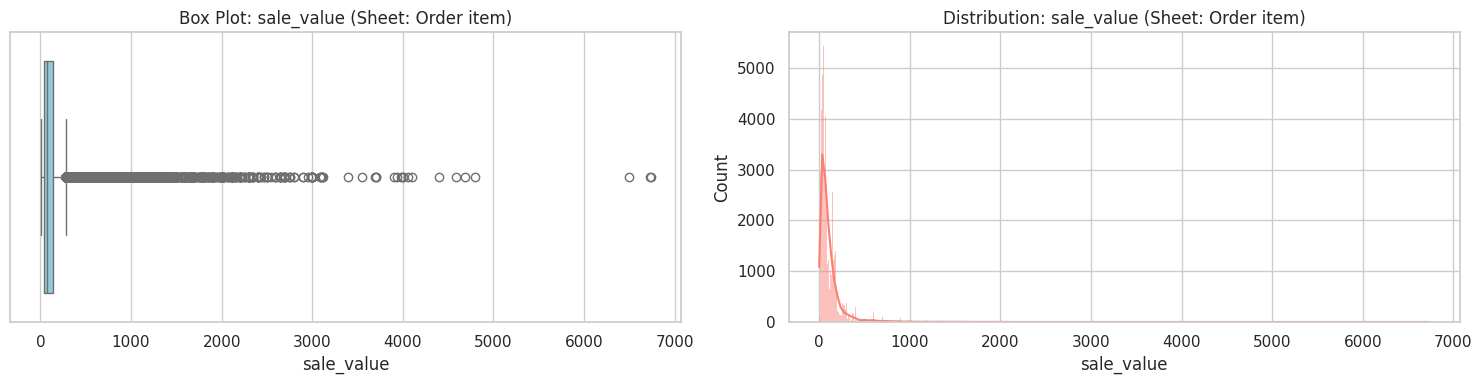

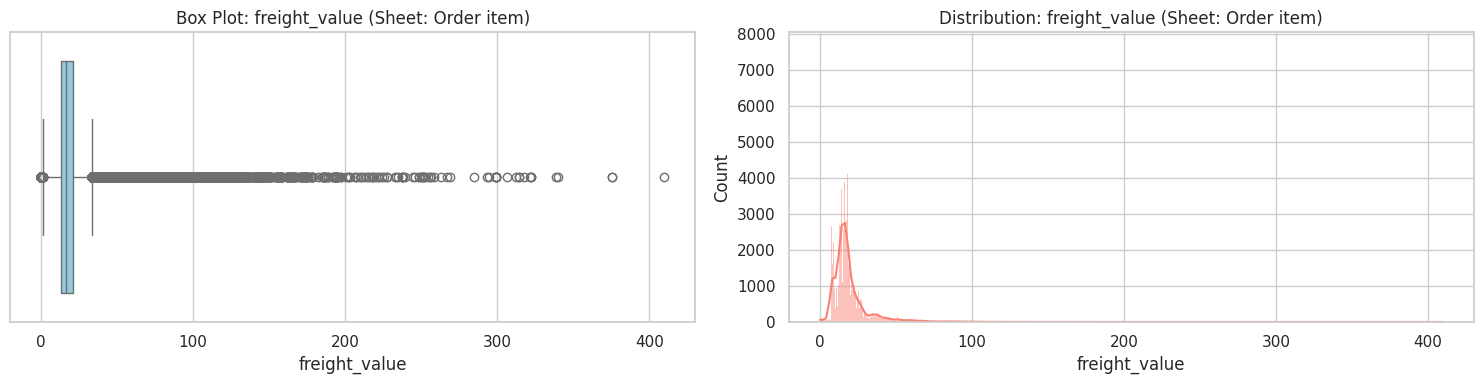


--- Đang xử lý file: Order Review.xlsx ---
 > Dữ liệu sheet 'Giải thích các field' không cần tiền xử lí (metadata hoặc giá trị không cần thiết cho tiền xử lí).


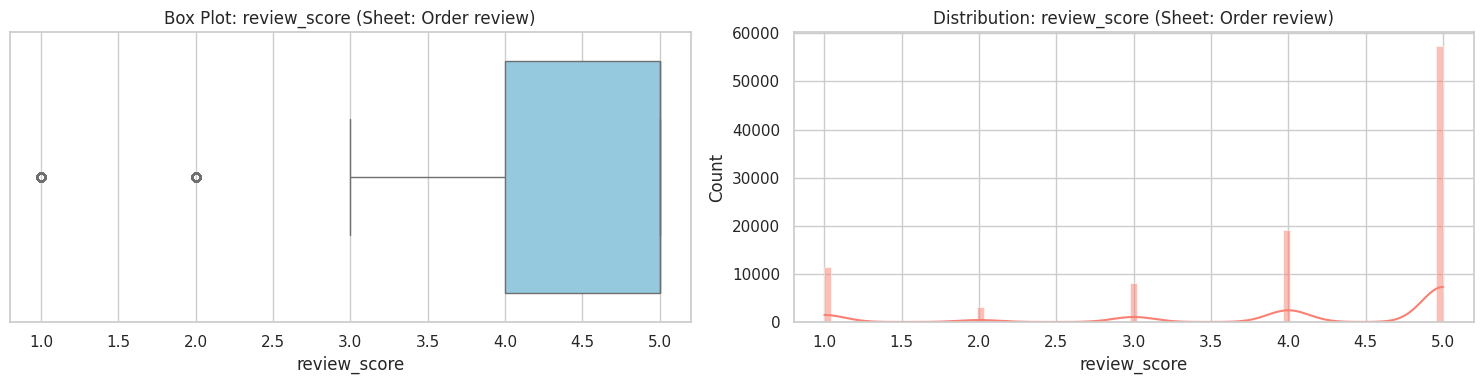

 > Dữ liệu sheet 'Translate review message' không cần tiền xử lí (metadata hoặc giá trị không cần thiết cho tiền xử lí).

--- Đang xử lý file: Order Payment.xlsx ---
 > Dữ liệu sheet 'Giải thích các field' không cần tiền xử lí (metadata hoặc giá trị không cần thiết cho tiền xử lí).


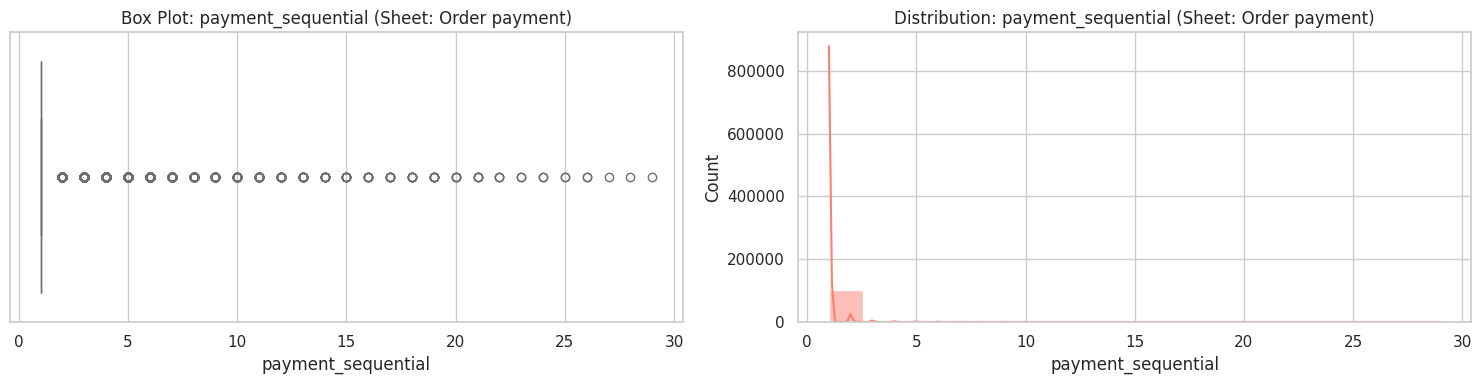

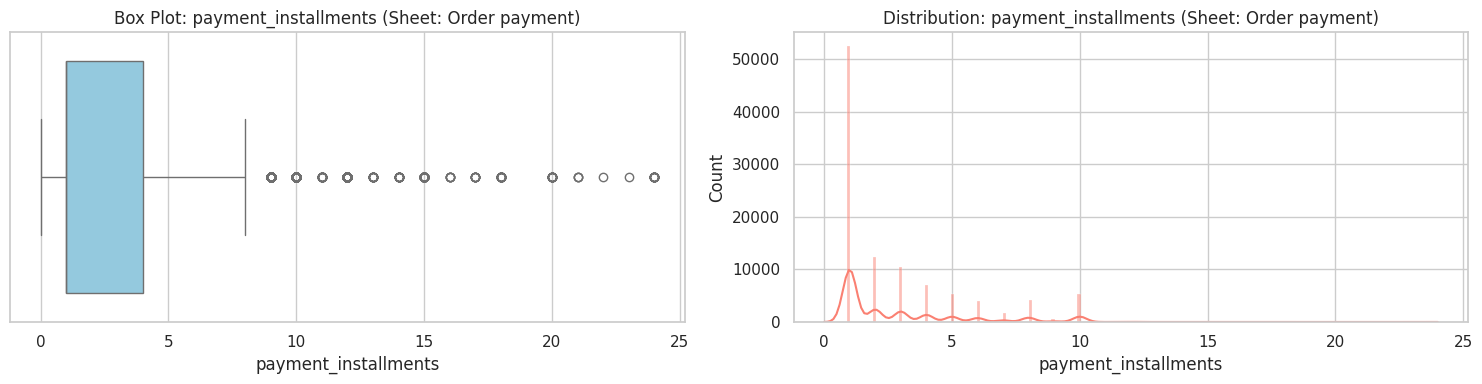

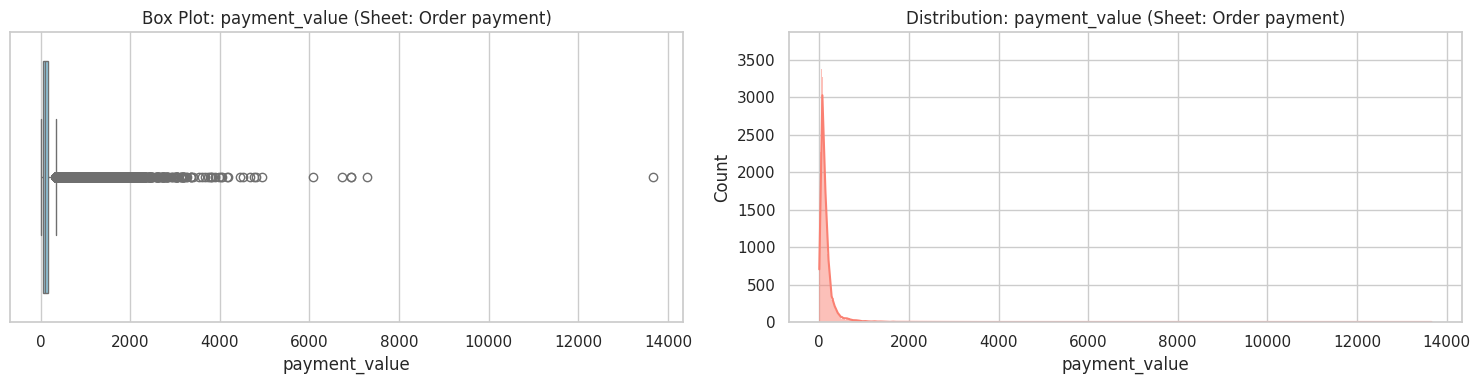


--- Đang xử lý file: Buyer.xlsx ---
 > Dữ liệu sheet 'Explanation' không cần tiền xử lí (metadata hoặc giá trị không cần thiết cho tiền xử lí).


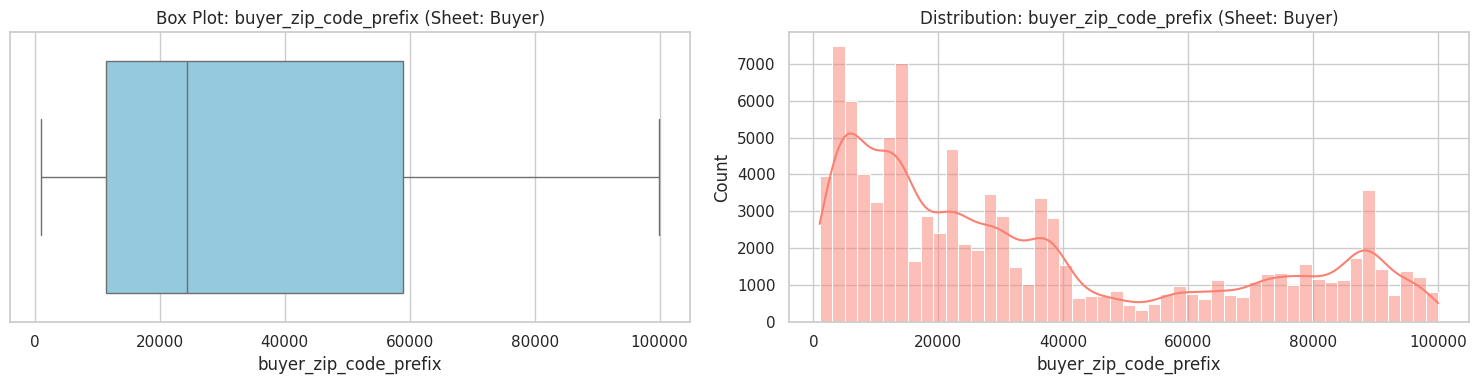


--- Đang xử lý file: Closed Deals.xlsx ---
 > Dữ liệu sheet 'Explanation' không cần tiền xử lí (metadata hoặc giá trị không cần thiết cho tiền xử lí).


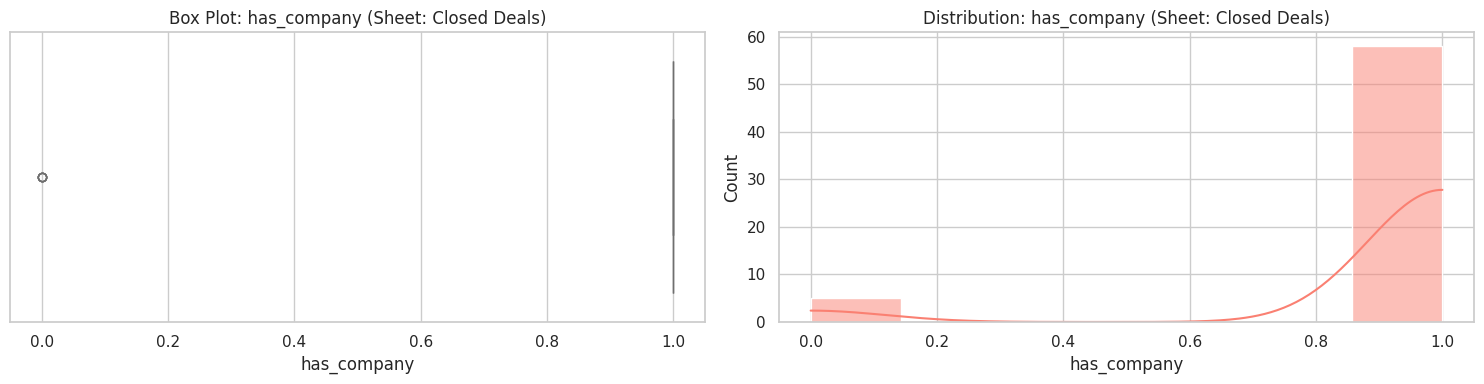

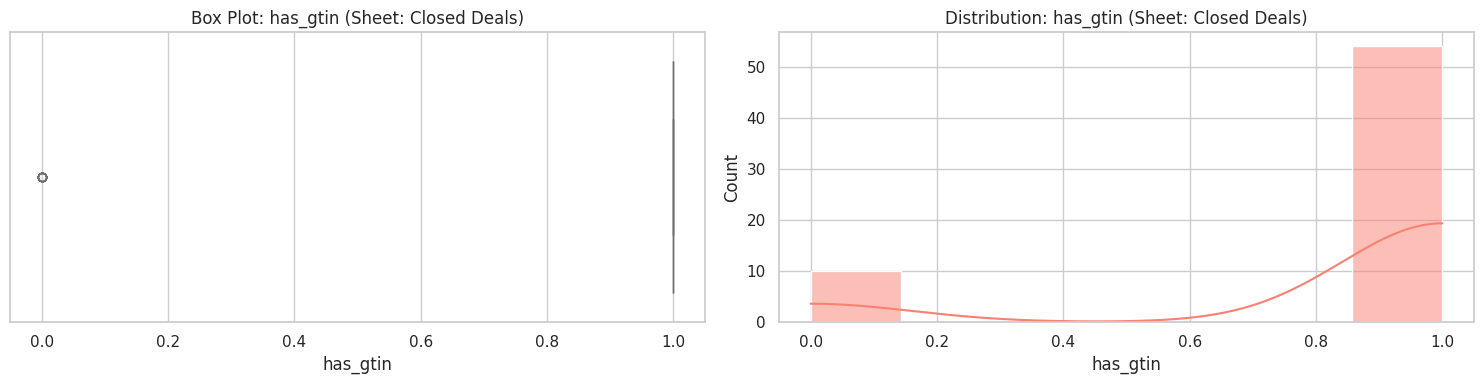

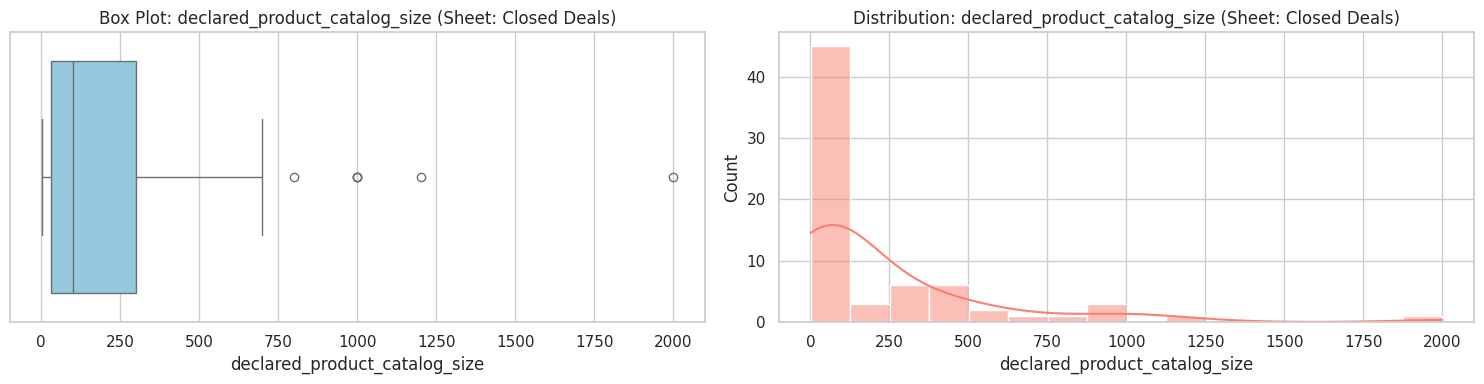

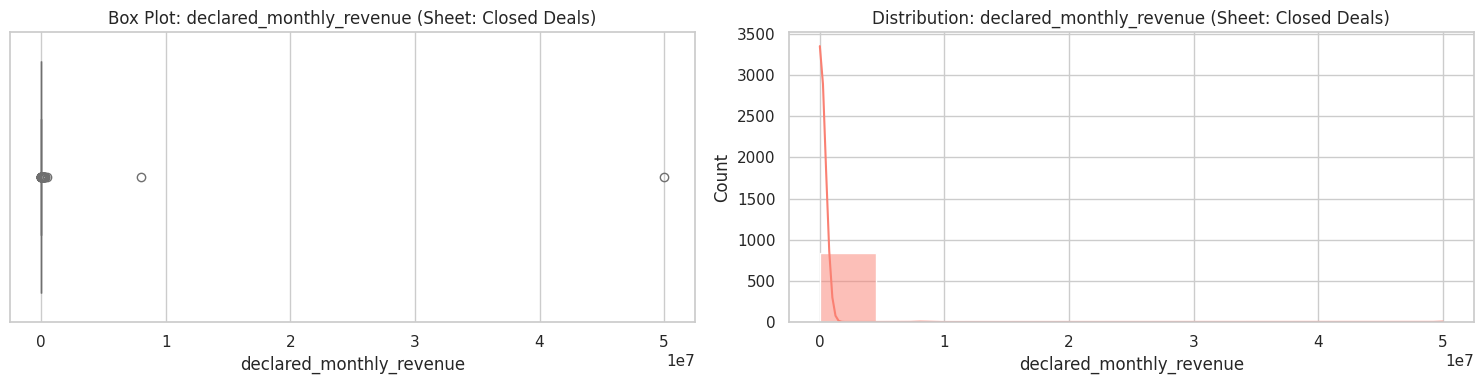


--- Đang xử lý file: Geolocation.xlsx ---
 > Dữ liệu sheet 'Giải thích thuật ngữ' không cần tiền xử lí (metadata hoặc giá trị không cần thiết cho tiền xử lí).


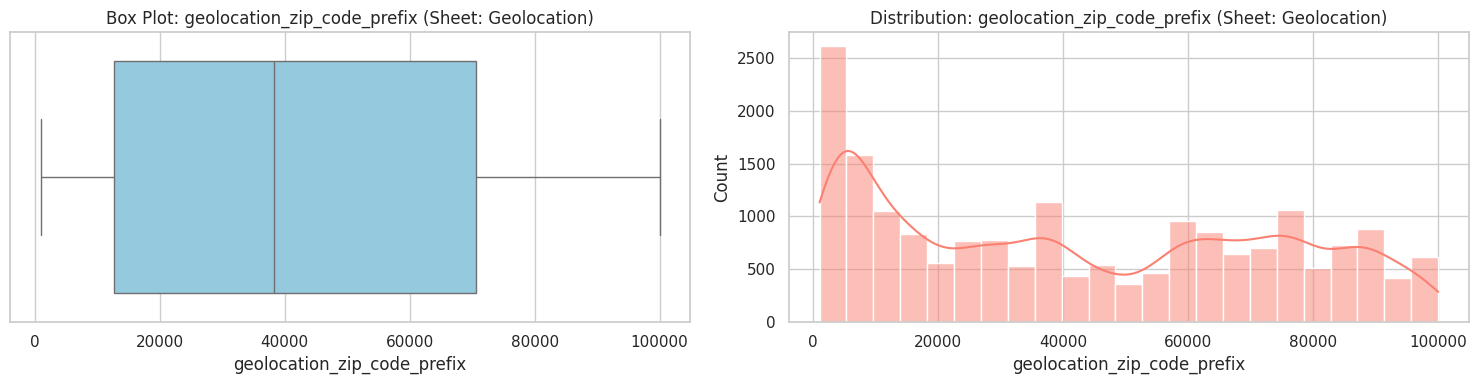

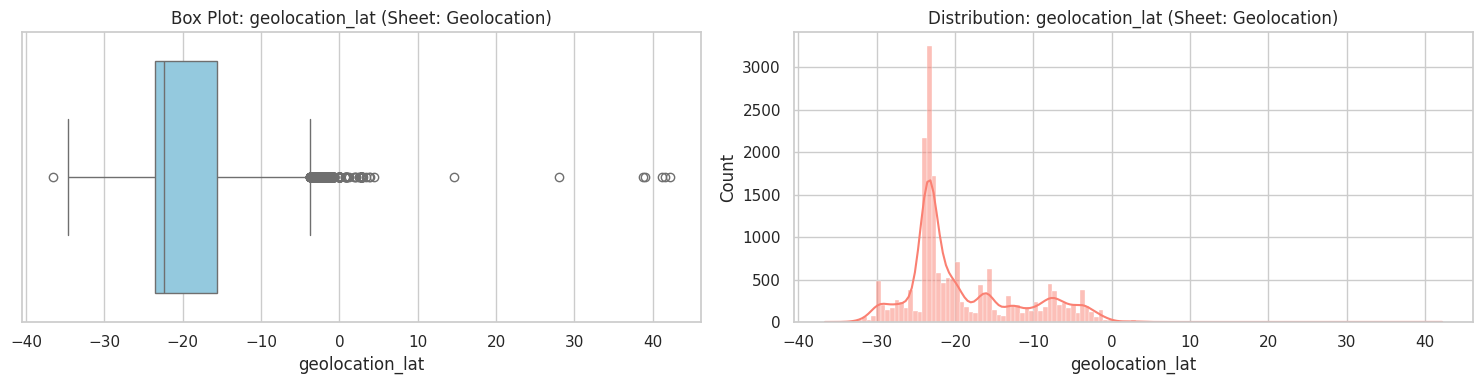

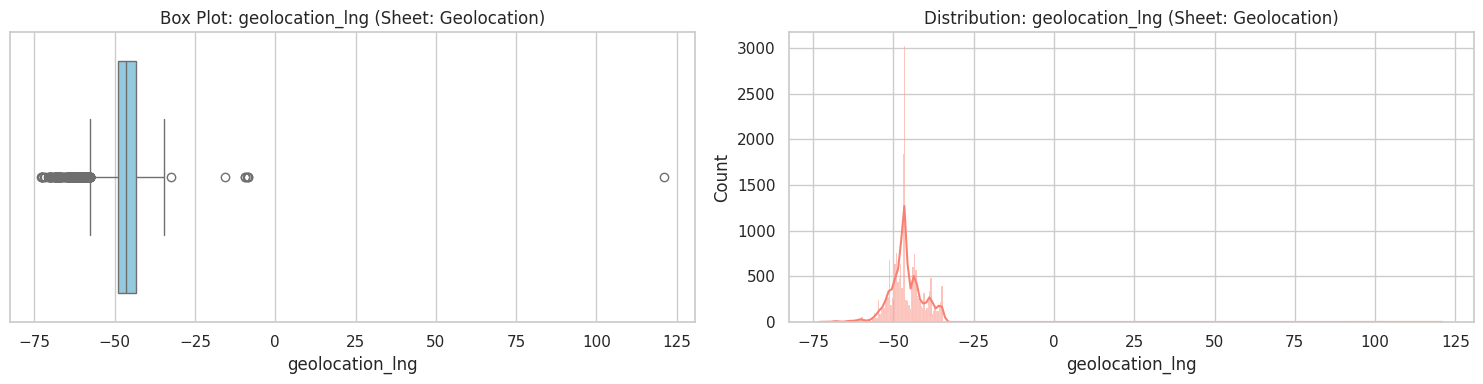


--- Đang xử lý file: Marketing Qualified Leads.xlsx ---
 > Dữ liệu sheet 'Explanation' không cần tiền xử lí (metadata hoặc giá trị không cần thiết cho tiền xử lí).
 > Dữ liệu sheet 'Marketing Qualified Leads' không cần tiền xử lí (metadata hoặc giá trị không cần thiết cho tiền xử lí).

--- Đang xử lý file: Product.xlsx ---
 > Dữ liệu sheet 'Explanation' không cần tiền xử lí (metadata hoặc giá trị không cần thiết cho tiền xử lí).


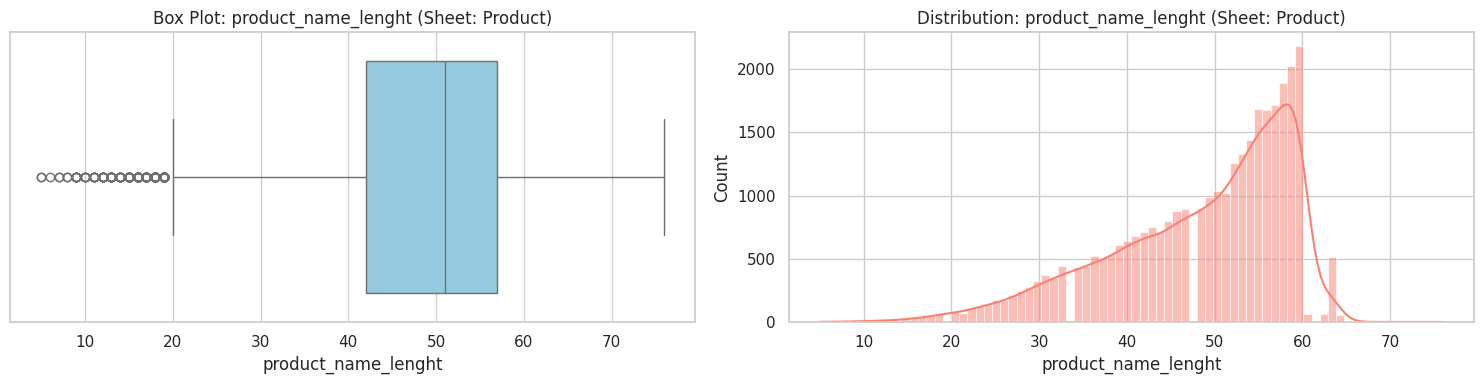

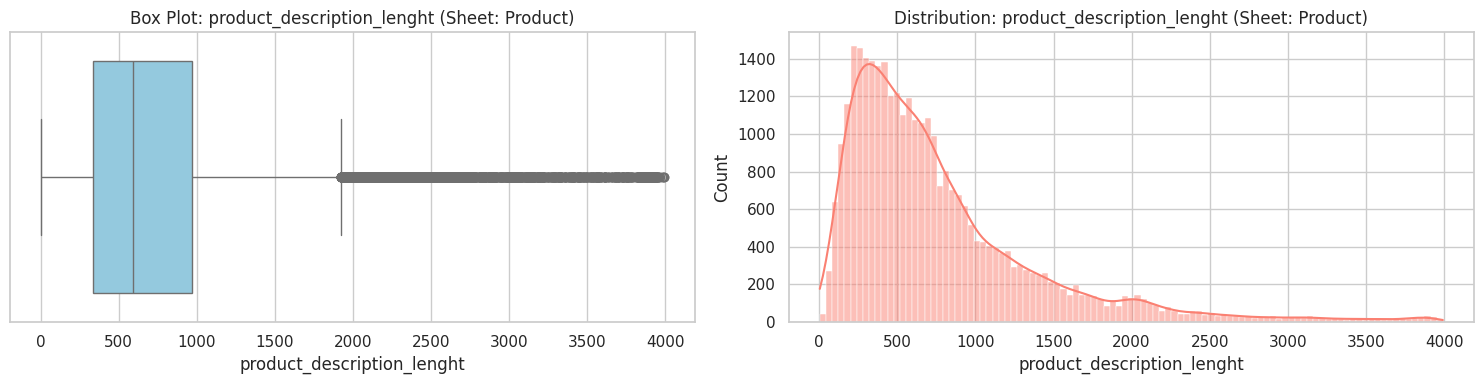

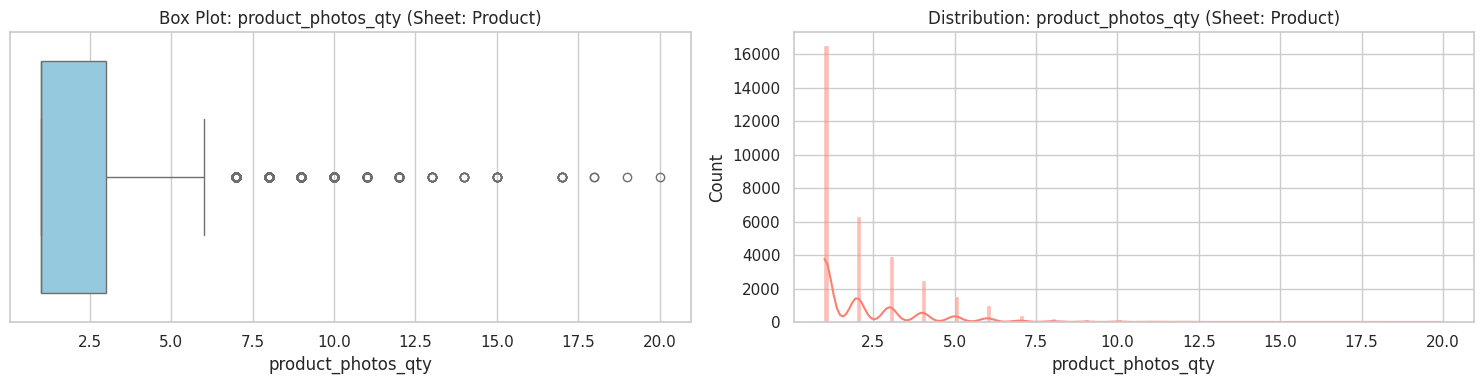

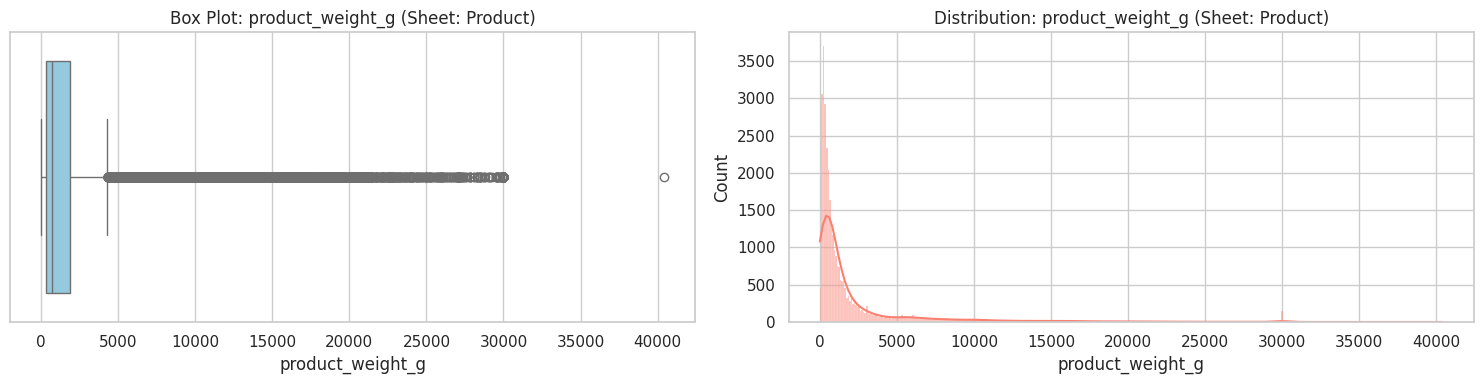

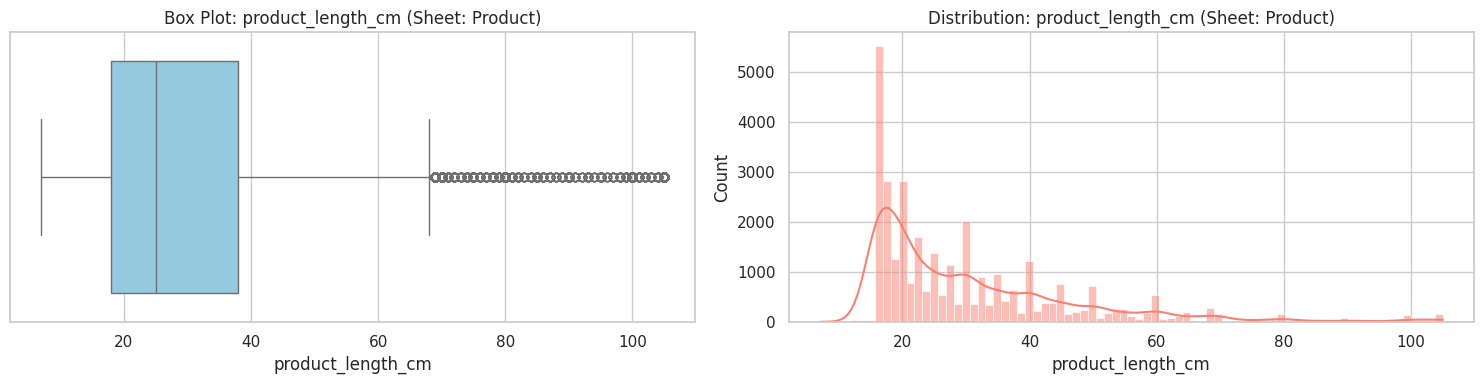

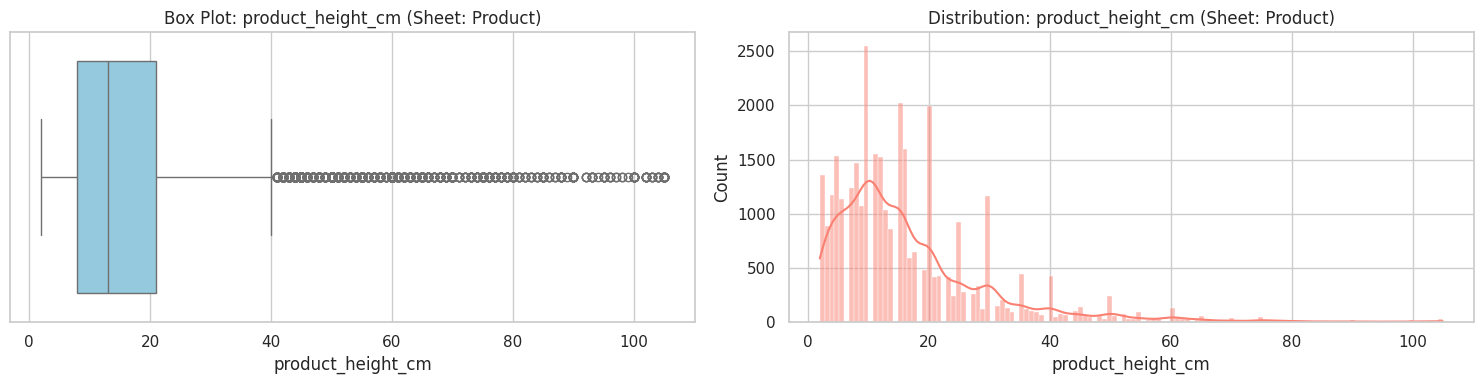

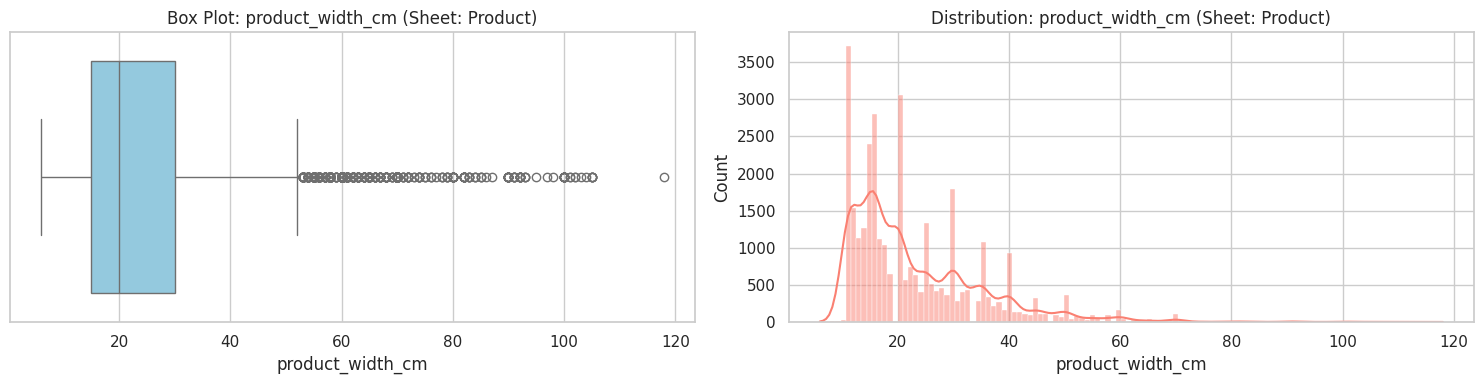


--- Đang xử lý file: Seller.xlsx ---
 > Dữ liệu sheet 'Giải thích thuật ngữ' không cần tiền xử lí (metadata hoặc giá trị không cần thiết cho tiền xử lí).


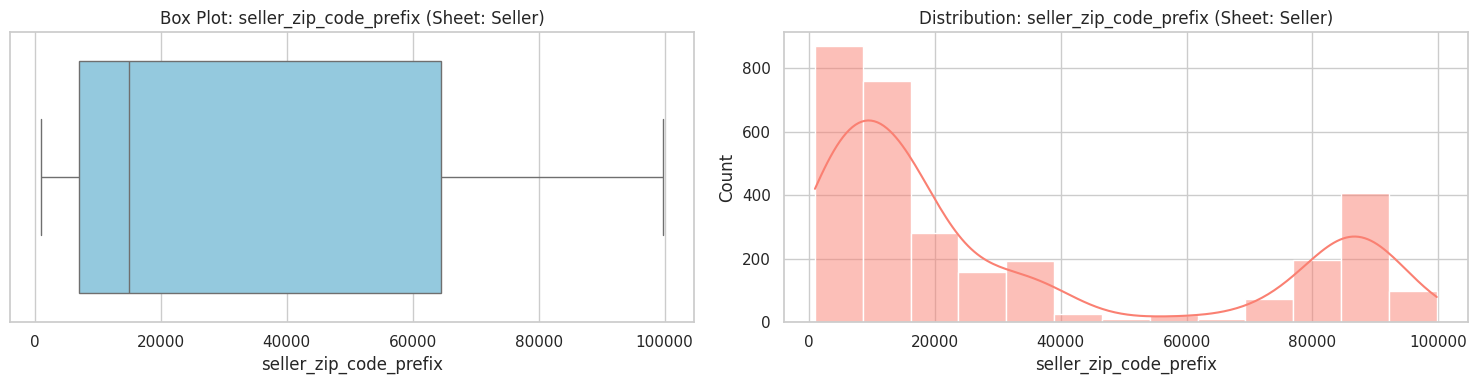

In [ ]:
all_files = [f for f in os.listdir(folder) if f.endswith('.xlsx')]
data_files = [f for f in all_files if 'Explanation' not in f]

print(f"Tìm thấy {len(data_files)} file dữ liệu: {data_files}")
sns.set_theme(style="whitegrid")
plt.rcParams['figure.max_open_warning'] = 0

# Vòng lặp For
for file_name in data_files:
    try:
        print(f"\n--- Đang xử lý file: {file_name} ---")

        # Đọc tất cả các sheet từ file Excel
        all_sheets_df = pd.read_excel(os.path.join(folder, file_name), sheet_name=None)

        if not all_sheets_df:
            print(f" > File {file_name} không có sheet.")
            del all_sheets_df
            gc.collect()
            continue

        for sheet_name, df_sheet in all_sheets_df.items():

            numeric_cols = df_sheet.select_dtypes(include=['number']).columns

            if len(numeric_cols) == 0:
                print(f" > Dữ liệu sheet '{sheet_name}' không cần tiền xử lí (metadata hoặc giá trị không cần thiết cho tiền xử lí).")
            else:
                for col in numeric_cols:
                    fig, axes = plt.subplots(1, 2, figsize=(15, 4))

                    # Box Plot
                    sns.boxplot(ax=axes[0], x=df_sheet[col], color='skyblue')
                    axes[0].set_title(f'Box Plot: {col} (Sheet: {sheet_name})')

                    # Dist plot
                    sns.histplot(ax=axes[1], x=df_sheet[col], kde=True, color='salmon')
                    axes[1].set_title(f'Distribution: {col} (Sheet: {sheet_name})')
                    plt.tight_layout()
                    plt.show()
                    plt.close(fig)
            del df_sheet
            gc.collect()
        del all_sheets_df
        gc.collect()
    except Exception as e:
        print(f" Lỗi khi xử lý file {file_name}: {e}")